In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import stanza

plt.style.use('ggplot')
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import nltk

try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    print("Downloads concluídos com sucesso.")
except Exception as e:
    print(f"Erro no download: {e}")

# %% [NOVO] — IMPORTS ADICIONAIS PARA FINE-TUNING E MODELOS DE INSTRUÇÕES
# Instalar se necessário:
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
import torch
from torch.utils.data import Dataset as TorchDataset
from transformers import pipeline
import requests
import json
import time


C:\Users\danie\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloads concluídos com sucesso.


Carregar dados

In [5]:
df_test  = pd.read_csv("../data/raw/Tweets_EN_sentiment_test.csv")
df_train = pd.read_csv("../data/raw/Tweets_EN_sentiment_train.csv")

print("Informação do dataset de teste:")
print(df_test.info())
print("\nInformação do dataset de treino:")
print(df_train.info())

Informação do dataset de teste:
<class 'pandas.DataFrame'>
RangeIndex: 2122 entries, 0 to 2121
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   tweet   2122 non-null   int64
 1   text    2100 non-null   str  
 2   class   2122 non-null   str  
dtypes: int64(1), str(2)
memory usage: 49.9 KB
None

Informação do dataset de treino:
<class 'pandas.DataFrame'>
RangeIndex: 47799 entries, 0 to 47798
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   tweet   47799 non-null  int64
 1   text    47527 non-null  str  
 2   class   47799 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.1 MB
None


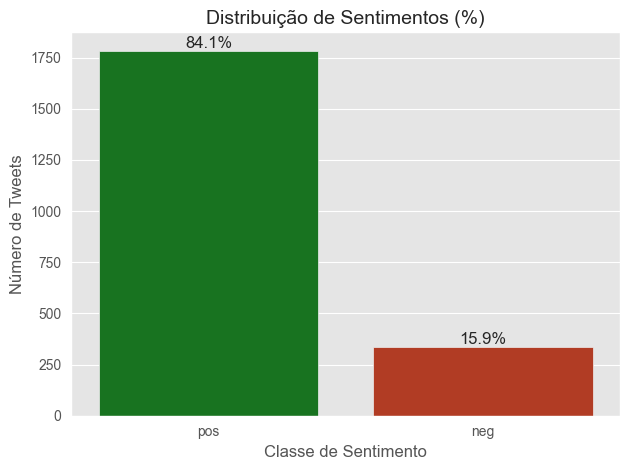

=== DISTRIBUIÇÃO DO DATASET DE TESTE ===
  pos: 1,784 tweets (84.1%)
  neg: 338 tweets (15.9%)

⚠️  Baseline trivial (sempre pos): F1 = 0.9135


In [21]:
cores = {'pos': '#098213', 'neg': "#C92D0C"}

ax = sns.countplot(data=df_test, x='class', hue='class', palette=cores, legend=False)

total = len(df_test['class'])

for p in ax.patches:
    percentagem = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentagem, (x, y), ha='center', va='bottom', fontsize=12)

plt.title('Distribuição de Sentimentos (%)', fontsize=14)
plt.xlabel('Classe de Sentimento', fontsize=12)
plt.ylabel('Número de Tweets', fontsize=12)
plt.tight_layout()
plt.show()



In [22]:
dist = df_test['class'].value_counts()
pct  = dist / len(df_test) * 100

# F1 de um classificador que diz sempre 'pos'
p_pos = pct['pos'] / 100
baseline_trivial_f1 = 2 * p_pos / (p_pos + 1.0)

print('=== DISTRIBUIÇÃO DO DATASET DE TESTE ===')
for cls in ['pos', 'neg']:
    print(f'  {cls}: {dist[cls]:,} tweets ({pct[cls]:.1f}%)')
print(f'\n⚠️  Baseline trivial (sempre pos): F1 = {baseline_trivial_f1:.4f}')

=== DISTRIBUIÇÃO DO DATASET DE TESTE ===
  pos: 1,784 tweets (84.1%)
  neg: 338 tweets (15.9%)

⚠️  Baseline trivial (sempre pos): F1 = 0.9135


In [8]:
stopwords_en = nltk.corpus.stopwords.words('english')

palavras_negacao = {
    'not', 'no', 'nor', 'never', 'none', 'nothing', 'nowhere', 'nobody',
    'against', "don't", "dont", "aren't", "arent", "couldn't", "couldnt",
    "didn't", "didnt", "doesn't", "doesnt", "hadn't", "hadnt",
    "hasn't", "hasnt", "haven't", "havent", "isn't", "isnt",
    "mightn't", "mightnt", "mustn't", "mustnt", "needn't", "neednt",
    "shan't", "shant", "shouldn't", "shouldnt", "wasn't", "wasnt",
    "weren't", "werent", "won't", "wont", "wouldn't", "wouldnt",
    "can't", "cant", "cannot"
}

stopwords_clean = [w for w in stopwords_en if w not in palavras_negacao]

## Pré-processamento

In [16]:
lemmatizer = WordNetLemmatizer()

def limpar_texto_base(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'\bUSER\b', '', text)
    text = re.sub(r'\bURL\b', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'^\s*RT\s+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^\w\s\?\!\']', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def processar_tokens(text, remove_stopwords=True, remove_numbers=False,
                     full_context=False, use_lemmatization=True):
    if not isinstance(text, str):
        return ""
    text = limpar_texto_base(text)
    if not text:
        return ""
    tokens = word_tokenize(text)
    tokens_limpos = []
    for w in tokens:
        if w in {'!', '?'}:
            tokens_limpos.append(w)
            continue
        if remove_numbers and re.fullmatch(r'\d+([.,:/-]\d+)*', w):
            continue
        if not re.search(r"[A-Za-z0-9#']", w):
            continue
        base = w
        if not base:
            continue
        if not full_context and remove_stopwords and base.lower() in stopwords_clean:
            continue
        if use_lemmatization:
            token_final = lemmatizer.lemmatize(base.lower())
        else:
            token_final = base.lower()
        if base.isupper() and len(base) > 1:
            token_final = token_final.upper()
        tokens_limpos.append(token_final)
    return ' '.join(tokens_limpos)

In [15]:
# Cenário A: Baseline (remove stopwords irrelevantes, mantém números e capitalização)
def prep_baseline(text):
    if not isinstance(text, str):
        return ""
    return processar_tokens(text, remove_stopwords=True, remove_numbers=False,
                            full_context=False, use_lemmatization=True)


# Cenário B: Full Context (mantém TODAS as stopwords)
def prep_full_context(text):
    if not isinstance(text, str):
        return ""
    return processar_tokens(text, remove_stopwords=False, remove_numbers=False,
                            full_context=True, use_lemmatization=True)


# Cenário C: Sem Lematização (baseline, mas sem lematizar)
def prep_sem_lematizacao(text):
    if not isinstance(text, str):
        return ""
    return processar_tokens(text, remove_stopwords=True, remove_numbers=False,
                            full_context=False, use_lemmatization=False)

In [17]:
# Aplicar cenários
df_test['text_baseline']         = df_test['text'].apply(prep_baseline)
df_test['text_full_context']     = df_test['text'].apply(prep_full_context)
df_test['text_sem_lematizacao']  = df_test['text'].apply(prep_sem_lematizacao)

df_train['text_baseline']        = df_train['text'].apply(prep_baseline)
df_train['text_full_context']    = df_train['text'].apply(prep_full_context)
df_train['text_sem_lematizacao'] = df_train['text'].apply(prep_sem_lematizacao)

Limpeza mínima para Transformers (não remover stopwords — BERT precisa de contexto)

In [18]:
def limpar_para_transformers(text):
    if not isinstance(text, str) or text.strip() == '':
        return ""
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'\bUSER\b', '', text)
    text = re.sub(r'\bURL\b', '', text)
    text = re.sub(r'^\s*RT\s+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_test['text_transformers']  = df_test['text'].apply(limpar_para_transformers)
df_train['text_transformers'] = df_train['text'].apply(limpar_para_transformers)

print("Pré-processamento concluído.")
print(df_test[['text', 'text_baseline', 'text_full_context', 'text_sem_lematizacao']].head(5))

Pré-processamento concluído.
                                                text  \
0                                   lmao  i love it.   
1  Never been to Australia, but I'll keep that in...   
2  Tired as shit...but what else is new...and don...   
3                                           Levi's!    
4  no sweetie, its not love, probably just heart ...   

                                       text_baseline  \
0                                          lmao love   
1  never australia 'll keep mind eat mcdonald 's ...   
2  tired shitbut else newand n't want go work day...   
3                                          levi 's !   
4  no sweetie not love probably heart burn get tw...   

                                   text_full_context  \
0                                     lmao i love it   
1  never been to australia but i 'll keep that in...   
2  tired a shitbut what else is newand do n't wan...   
3                                          levi 's !   
4  no sweetie it 

Avaliação dos diferentes modelos

In [19]:
def avaliar_modelo(y_true, y_pred, nome_modelo, nome_cenario):
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, pos_label='pos', zero_division=0)
    rec   = recall_score(y_true, y_pred, pos_label='pos', zero_division=0)
    f1    = f1_score(y_true, y_pred, pos_label='pos', zero_division=0)
    return {
        'Cenário': nome_cenario,
        'Modelo': nome_modelo,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    }

# [NOVO] — Baseline trivial (sempre prediz 'pos') — referência obrigatória
y_true_test = df_test['class']
y_baseline_trivial = ['pos'] * len(df_test)

resultado_baseline_trivial = avaliar_modelo(
    y_true_test, y_baseline_trivial,
    'Always-POS (Trivial)', 'Baseline Trivial'
)
print("\nBaseline Trivial (referência):")
print(pd.DataFrame([resultado_baseline_trivial]))

# Inicializar lista de resultados COM o baseline trivial
df_resultados = pd.DataFrame([resultado_baseline_trivial])


Baseline Trivial (referência):
            Cenário                Modelo  Accuracy  Precision  Recall  \
0  Baseline Trivial  Always-POS (Trivial)    0.8407     0.8407     1.0   

   F1-Score  
0    0.9135  


In [20]:
analyzer_vader = SentimentIntensityAnalyzer()
# stanza.download('en')  # executar apenas na primeira vez
nlp_stanza = stanza.Pipeline('en', processors='tokenize,sentiment', verbose=False)

def classificar_textblob(text):
    if not text or text.strip() == '':
        return 'pos'
    polarity = TextBlob(text).sentiment.polarity
    return 'pos' if polarity >= 0 else 'neg'


def classificar_vader(text):
    if not text or text.strip() == '':
        return 'pos'
    scores   = analyzer_vader.polarity_scores(text)
    compound = scores['compound']
    return 'pos' if compound >= 0.0 else 'neg'


def classificar_stanza(text):
    if not text or text.strip() == '':
        return 'pos'
    try:
        doc        = nlp_stanza(text)
        sentimentos = [s.sentiment for s in doc.sentences]
        media       = np.mean(sentimentos) if sentimentos else 1.0
        return 'pos' if media >= 1.0 else 'neg'
    except Exception:
        return 'pos'


# %% [ORIGINAL] — Aplicar modelos aos 3 cenários
cenarios = ['text_baseline', 'text_full_context', 'text_sem_lematizacao']
modelos  = ['textblob', 'vader', 'stanza']

nomes_cenarios = {
    'text_baseline':        'Baseline',
    'text_full_context':    'Full Context',
    'text_sem_lematizacao': 'Sem Lematização'
}

for cenario in cenarios:
    print(f"Processando cenário: {cenario}")
    df_test[f'{cenario}_pred_textblob'] = df_test[cenario].apply(classificar_textblob)
    df_test[f'{cenario}_pred_vader']    = df_test[cenario].apply(classificar_vader)
    df_test[f'{cenario}_pred_stanza']   = df_test[cenario].apply(classificar_stanza)

print("Classificações lexicais concluídas!")

for cenario in cenarios:
    for modelo in modelos:
        col_pred  = f'{cenario}_pred_{modelo}'
        resultado = avaliar_modelo(
            y_true_test, df_test[col_pred],
            modelo.upper(), nomes_cenarios[cenario]
        )
        df_resultados = pd.concat(
            [df_resultados, pd.DataFrame([resultado])], ignore_index=True
        )

print("\nResultados lexicais acumulados:")
print(df_resultados)

Processando cenário: text_baseline
Processando cenário: text_full_context
Processando cenário: text_sem_lematizacao
Classificações lexicais concluídas!

Resultados lexicais acumulados:
            Cenário                Modelo  Accuracy  Precision  Recall  \
0  Baseline Trivial  Always-POS (Trivial)    0.8407     0.8407  1.0000   
1          Baseline              TEXTBLOB    0.8101     0.8763  0.9013   
2          Baseline                 VADER    0.8172     0.8957  0.8857   
3          Baseline                STANZA    0.7776     0.9020  0.8251   
4      Full Context              TEXTBLOB    0.8054     0.8777  0.8929   
5      Full Context                 VADER    0.8214     0.8953  0.8918   
6      Full Context                STANZA    0.7630     0.9093  0.7976   
7   Sem Lematização              TEXTBLOB    0.8124     0.8783  0.9019   
8   Sem Lematização                 VADER    0.8190     0.8973  0.8862   
9   Sem Lematização                STANZA    0.7743     0.9020  0.8206   

